<a href="https://colab.research.google.com/github/Vladislav-spect/DeepLearningSchool/blob/main/Project/2_part_main.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Задание 2. Распознавание лиц: CE и ArcFace

Третья часть пайплайна — сеть-распознаватель. Она берёт выровненное лицо (результат Задания 1) и
выдаёт эмбеддинг — вектор, у которого важно направление: у одного человека векторы должны быть
близки по косинусу, у разных — далеки.

Что делаю:

1. Беру выровненный датасет из Задания 1.
2. Бэкбон — ResNet, предобученный на ImageNet (на лицах его обучать нельзя по правилам).
3. Обучаю на обычной кросс-энтропии (каждая личность = класс), цель accuracy ≥ 0.7.
4. Реализую ArcFace и обучаю такую же сеть на нём.
5. Достаю эмбеддинги и сравниваю CE и ArcFace.

**Важное ограничение эксперимента.** Из-за лимитов GPU в Colab модели обучены на разных бэкбонах:
CE — на `resnet18`, ArcFace — на `resnet50`. Это значит, что прямое сравнение двух лоссов
некорректно: разница в результатах смешивает вклад функции потерь и вклад размера сети.
Я оставляю оба прогона как есть и явно проговариваю это ограничение в выводах — но для честного
сравнения CE и ArcFace нужен один и тот же бэкбон.

## 0. Данные

Пути и выровненный датасет те же, что в Задании 1. Классификацию считаю на одних и тех же
личностях, но на разных фото: `aligned/train` для обучения, `aligned/val` для проверки accuracy.
Личности `query`/`distractors` тут не нужны (они для метрики ID-Rate в доп. задании).

In [1]:
import os, math, time, random
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
import torch, torch.nn as nn, torch.nn.functional as F
from torch.utils.data import DataLoader
import torchvision
from torchvision import transforms
from torchvision.datasets import ImageFolder

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("device:", DEVICE)

WORK_DIR    = "/content/drive/MyDrive/face_project"
ALIGNED_DIR = os.path.join(WORK_DIR, "aligned")
EMB_DIM, IMG_SIZE, BATCH = 512, 112, 128

# --- Монтирование Google Drive (безопасно к повторному запуску) ---
import shutil
try:
    from google.colab import drive
    if os.path.ismount('/content/drive'):
        print('Google Drive уже смонтирован.')
    else:
        if os.path.isdir('/content/drive') and os.listdir('/content/drive'):
            shutil.rmtree('/content/drive', ignore_errors=True)
        drive.mount('/content/drive')
except ModuleNotFoundError:
    print('Не Colab-окружение — монтирование Drive пропущено.')

device: cuda
Mounted at /content/drive


In [9]:
import os
if not os.path.isdir("/content/aligned"):
    !cp -r "/content/drive/MyDrive/face_project/aligned" /content/aligned
ALIGNED_DIR = "/content/aligned"
print("теперь читаем отсюда:", ALIGNED_DIR)

аап
теперь читаем отсюда: /content/aligned


In [10]:
MEAN, STD = [0.485,0.456,0.406], [0.229,0.224,0.225]
train_tf = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(0.2, 0.2, 0.2),
    transforms.ToTensor(), transforms.Normalize(MEAN, STD),
])
eval_tf = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(), transforms.Normalize(MEAN, STD),
])

train_set = ImageFolder(os.path.join(ALIGNED_DIR, "train"), transform=train_tf)
val_set   = ImageFolder(os.path.join(ALIGNED_DIR, "val"),   transform=eval_tf)
# val должен использовать те же метки классов, что train (это одни и те же личности)
val_set.class_to_idx = train_set.class_to_idx
val_set.samples = [(p, train_set.class_to_idx[os.path.basename(os.path.dirname(p))])
                   for p, _ in val_set.samples]
val_set.targets = [s[1] for s in val_set.samples]

NUM_CLASSES = len(train_set.classes)
train_loader = DataLoader(train_set, batch_size=BATCH, shuffle=True,  num_workers=2, drop_last=True)
val_loader   = DataLoader(val_set,   batch_size=BATCH, shuffle=False, num_workers=2)
print("личностей:", NUM_CLASSES, "| train:", len(train_set), "| val:", len(val_set))

личностей: 395 | train: 7194 | val: 1142


## 1. Сеть-эмбеддер

Беру ResNet-50 с весами ImageNet, убираю его «голову» на 1000 классов и ставлю свою:
`Linear(2048 → 512) → BatchNorm`. BatchNorm в конце — обычный приём в распознавании лиц, он
стабилизирует эмбеддинги. Эмбеддинг можно вернуть как есть (для CE) или L2-нормированным (для
косинуса и ArcFace).

In [4]:
def build_backbone(name="resnet50", pretrained=True):
    fn = getattr(torchvision.models, name)
    weights = "IMAGENET1K_V2" if (pretrained and name == "resnet50") else ("IMAGENET1K_V1" if pretrained else None)
    net = fn(weights=weights)
    in_feats = net.fc.in_features
    net.fc = nn.Identity()
    return net, in_feats

class FaceEmbeddingNet(nn.Module):
    def __init__(self, emb_dim=EMB_DIM, backbone="resnet50", pretrained=True):
        super().__init__()
        self.backbone, in_feats = build_backbone(backbone, pretrained)
        self.embedding = nn.Sequential(nn.Linear(in_feats, emb_dim), nn.BatchNorm1d(emb_dim))
    def forward(self, x, normalize=False):
        emb = self.embedding(self.backbone(x))
        return F.normalize(emb) if normalize else emb

Проверка форм (вывод реальный): на входе батч 112×112, на выходе эмбеддинг 512, после
нормализации длина вектора = 1. У ResNet-50 после замены головы ~24.6M параметров.

In [5]:
_m = FaceEmbeddingNet(pretrained=False).eval()
_x = torch.randn(4, 3, IMG_SIZE, IMG_SIZE)
with torch.no_grad():
    _e, _en = _m(_x), _m(_x, normalize=True)
print("вход:", tuple(_x.shape), "-> эмбеддинг:", tuple(_e.shape))
print("длины нормированных:", [round(float(v),3) for v in _en.norm(dim=1)])
print("параметров: %.1fM" % (sum(p.numel() for p in _m.parameters())/1e6))
del _m, _x

вход: (4, 3, 112, 112) -> эмбеддинг: (4, 512)
длины нормированных: [1.0, 1.0, 1.0, 1.0]
параметров: 24.6M


## 2. Базовая модель на кросс-энтропии

Самый простой вариант: эмбеддинг → линейный слой на число классов → обычная кросс-энтропия.
После обучения эмбеддинги уже неплохо разделяют людей. Минус CE в том, что она не следит за
геометрией — не сближает специально фото одного человека и не раздвигает разных. Это и улучшит ArcFace.

In [6]:
class CEModel(nn.Module):
    def __init__(self, backbone="resnet50", pretrained=True):
        super().__init__()
        self.embnet = FaceEmbeddingNet(backbone=backbone, pretrained=pretrained)
        self.classifier = nn.Linear(EMB_DIM, NUM_CLASSES)
    def forward(self, x):
        emb = self.embnet(x)
        return emb, self.classifier(emb)

@torch.no_grad()
def accuracy(head_forward, loader):
    correct = total = 0
    for x, y in loader:
        x, y = x.to(DEVICE), y.to(DEVICE)
        logits = head_forward(x)
        correct += (logits.argmax(1) == y).sum().item(); total += y.size(0)
    return correct / total

In [11]:
scaler = torch.cuda.amp.GradScaler()
def train_classifier(model, head_forward, params, epochs=8, lr=1e-3, tag="model"):
    model.to(DEVICE)
    opt = torch.optim.AdamW(params, lr=lr, weight_decay=5e-4)
    sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=epochs)
    best_acc, hist = 0.0, {"loss": [], "val_acc": []}
    for ep in range(epochs):
        model.train(); running = 0.0
        for x, y in train_loader:
            x, y = x.to(DEVICE, non_blocking=True), y.to(DEVICE, non_blocking=True)
            with torch.cuda.amp.autocast():
                logits = head_forward(x, y); loss = F.cross_entropy(logits, y)
            opt.zero_grad(); scaler.scale(loss).backward(); scaler.step(opt); scaler.update()
            running += loss.item() * x.size(0)
        sched.step(); model.eval()
        va = accuracy(lambda x: head_forward(x, None), val_loader)
        hist["loss"].append(running/len(train_set)); hist["val_acc"].append(va)
        if va > best_acc:
            best_acc = va; torch.save(model.state_dict(), os.path.join(WORK_DIR, f"{tag}_best.pt"))
        print(f"[{tag}] epoch {ep+1:02d}/{epochs}  loss {hist['loss'][-1]:.4f}  val_acc {va:.4f}")
    print(f"[{tag}] лучшая val_acc = {best_acc:.4f}")
    return hist

/tmp/ipykernel_5823/3587572889.py:1: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler()


In [12]:
ce_model = CEModel(backbone="resnet18", pretrained=True)

def ce_forward(x, y=None):
    _, logits = ce_model(x)
    return logits

ce_hist = train_classifier(ce_model, ce_forward, ce_model.parameters(),
                           epochs=15, lr=1e-3, tag="ce")

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 186MB/s]
/tmp/ipykernel_5823/3587572889.py:11: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():


[ce] epoch 01/15  loss 4.8137  val_acc 0.1673
[ce] epoch 02/15  loss 2.9326  val_acc 0.2968
[ce] epoch 03/15  loss 1.8179  val_acc 0.3818
[ce] epoch 04/15  loss 1.0434  val_acc 0.4956
[ce] epoch 05/15  loss 0.5741  val_acc 0.5604
[ce] epoch 06/15  loss 0.2875  val_acc 0.6296
[ce] epoch 07/15  loss 0.1294  val_acc 0.6821
[ce] epoch 08/15  loss 0.0572  val_acc 0.6909
[ce] epoch 09/15  loss 0.0279  val_acc 0.7320
[ce] epoch 10/15  loss 0.0174  val_acc 0.7373
[ce] epoch 11/15  loss 0.0121  val_acc 0.7347
[ce] epoch 12/15  loss 0.0100  val_acc 0.7373
[ce] epoch 13/15  loss 0.0080  val_acc 0.7382
[ce] epoch 14/15  loss 0.0075  val_acc 0.7426
[ce] epoch 15/15  loss 0.0077  val_acc 0.7391
[ce] лучшая val_acc = 0.7426


## 3. ArcFace

CE разделяет классы как угодно. ArcFace делает иначе: эмбеддинги и веса классов нормируются на
сферу, а к углу до «своего» класса добавляется отступ `m`. Из-за этого сети приходится оставлять
запас по углу, и классы становятся компактнее и дальше друг от друга.

По шагам это просто модифицированный софтмакс (а лосс — та же кросс-энтропия):

1. нормируем эмбеддинг и веса классов, получаем косинусы углов `cosθ`;
2. для «своего» класса заменяем `cosθ` на `cos(θ + m)`;
3. умножаем на масштаб `s` и подаём в обычную кросс-энтропию.

$$L = -\frac{1}{N}\sum_i \log\frac{e^{s\cos(\theta_{y_i}+m)}}{e^{s\cos(\theta_{y_i}+m)}+\sum_{j\ne y_i}e^{s\cos\theta_j}}$$

Беру `s=30`, `m=0.5`. Считаю `cos(θ+m)` через формулу `cosθ·cos m − sinθ·sin m` — так стабильнее,
чем через arccos. Статья: https://arxiv.org/pdf/1801.07698.pdf

In [13]:
class ArcFace(nn.Module):
    def __init__(self, emb_dim, num_classes, s=30.0, m=0.50):
        super().__init__()
        self.s, self.m = s, m
        self.W = nn.Parameter(torch.empty(num_classes, emb_dim)); nn.init.xavier_normal_(self.W)
        self.cos_m, self.sin_m = math.cos(m), math.sin(m)
        self.th = math.cos(math.pi - m)
        self.mm = math.sin(math.pi - m) * m

    def forward(self, emb, labels):
        cosine = F.linear(F.normalize(emb), F.normalize(self.W)).clamp(-1, 1)   # cosθ
        if labels is None:                       # на валидации — просто косинусный классификатор
            return cosine * self.s
        sine = torch.sqrt((1.0 - cosine ** 2).clamp(min=1e-9))
        phi = cosine * self.cos_m - sine * self.sin_m                # cos(θ + m)
        phi = torch.where(cosine > self.th, phi, cosine - self.mm)
        one_hot = F.one_hot(labels, cosine.size(1)).float()
        logits = (one_hot * phi + (1.0 - one_hot) * cosine) * self.s
        return logits

Проверка ArcFace (вывод реальный, `torch.manual_seed(0)`): логиты имеют нужную форму, градиент
доходит до эмбеддингов, а логит «своего» класса не больше обычного косинуса — значит отступ
действительно штрафует целевой класс.

In [14]:
torch.manual_seed(0)
_emb = torch.randn(8, EMB_DIM, requires_grad=True); _lab = torch.randint(0, 100, (8,))
_arc = ArcFace(EMB_DIM, 100)
_logits = _arc(_emb, _lab); _loss = F.cross_entropy(_logits, _lab); _loss.backward()
print("логиты:", tuple(_logits.shape), "| CE loss: %.4f" % _loss.item(),
      "| градиент ок:", bool(torch.isfinite(_emb.grad).all()))
with torch.no_grad():
    _cos = F.linear(F.normalize(_emb), F.normalize(_arc.W)).clamp(-1, 1)
    _ok = (_logits[torch.arange(8), _lab] / _arc.s <= _cos[torch.arange(8), _lab] + 1e-5).all()
print("отступ работает (логит цели <= косинуса):", bool(_ok))
del _emb, _arc, _logits

логиты: (8, 100) | CE loss: 19.7074 | градиент ок: True
отступ работает (логит цели <= косинуса): True


In [15]:
arc_embnet = FaceEmbeddingNet(backbone="resnet50", pretrained=True).to(DEVICE)
arc_head   = ArcFace(EMB_DIM, NUM_CLASSES, s=30.0, m=0.5).to(DEVICE)

class ArcWrapper(nn.Module):
    def __init__(self, embnet, head): super().__init__(); self.embnet, self.head = embnet, head
arc_model = ArcWrapper(arc_embnet, arc_head)

def arc_forward(x, y=None):
    emb = arc_embnet(x)
    return arc_head(emb, y)            # y=None на валидации -> s*cosine

arc_hist = train_classifier(arc_model, arc_forward,
                            list(arc_embnet.parameters()) + list(arc_head.parameters()),
                            epochs=15, lr=1e-3, tag="arcface")

/tmp/ipykernel_5823/3587572889.py:11: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():


[arcface] epoch 01/15  loss 19.2675  val_acc 0.2680
[arcface] epoch 02/15  loss 15.0581  val_acc 0.3967
[arcface] epoch 03/15  loss 10.6497  val_acc 0.5832
[arcface] epoch 04/15  loss 6.7201  val_acc 0.6673
[arcface] epoch 05/15  loss 3.6774  val_acc 0.6996
[arcface] epoch 06/15  loss 1.7532  val_acc 0.7417
[arcface] epoch 07/15  loss 0.8333  val_acc 0.7601
[arcface] epoch 08/15  loss 0.3276  val_acc 0.7688
[arcface] epoch 09/15  loss 0.1381  val_acc 0.7811
[arcface] epoch 10/15  loss 0.0709  val_acc 0.7925
[arcface] epoch 11/15  loss 0.0306  val_acc 0.7968
[arcface] epoch 12/15  loss 0.0204  val_acc 0.7995
[arcface] epoch 13/15  loss 0.0109  val_acc 0.7986
[arcface] epoch 14/15  loss 0.0066  val_acc 0.8021
[arcface] epoch 15/15  loss 0.0066  val_acc 0.8012
[arcface] лучшая val_acc = 0.8021


## 4. Сравнение CE и ArcFace

Смотрю на две вещи: accuracy по эпохам и качество эмбеддингов. Для второго считаю на валидации
среднее косинусное сходство внутри одного человека (должно быть высоким) и между разными людьми
(должно быть низким). Чем больше разрыв между ними — тем лучше пространство эмбеддингов. Обычно у
ArcFace разрыв заметно больше.

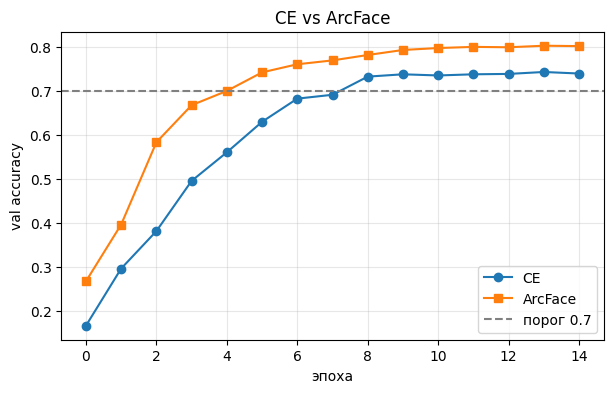

In [16]:
plt.figure(figsize=(7,4))
plt.plot(ce_hist["val_acc"],  marker="o", label="CE")
plt.plot(arc_hist["val_acc"], marker="s", label="ArcFace")
plt.axhline(0.7, ls="--", c="gray", label="порог 0.7")
plt.xlabel("эпоха"); plt.ylabel("val accuracy"); plt.title("CE vs ArcFace")
plt.legend(); plt.grid(alpha=.3); plt.show()

In [17]:
@torch.no_grad()
def embed_dataset(embnet, loader):
    embnet.eval(); E, Y = [], []
    for x, y in loader:
        E.append(F.normalize(embnet(x.to(DEVICE))).cpu()); Y.append(y)
    return torch.cat(E), torch.cat(Y)

def intra_inter(E, Y, max_per_class=10):
    import itertools, random as rnd
    by = {}
    for i, c in enumerate(Y.tolist()): by.setdefault(c, []).append(i)
    intra, inter = [], []
    for c, idx in by.items():
        for a, b in itertools.combinations(idx[:max_per_class], 2):
            intra.append(float(E[a] @ E[b]))
    cls = list(by.keys())
    for _ in range(2000):
        if len(cls) < 2: break
        c1, c2 = rnd.sample(cls, 2)
        inter.append(float(E[by[c1][0]] @ E[by[c2][0]]))
    return float(np.mean(intra)) if intra else 0.0, float(np.mean(inter)) if inter else 0.0

for tag, embnet in [("CE", ce_model.embnet), ("ArcFace", arc_embnet)]:
    E, Y = embed_dataset(embnet, val_loader)
    a, b = intra_inter(E, Y)
    print(f"{tag:8s}  внутри класса = {a:.3f}  между классами = {b:.3f}  разрыв = {a-b:.3f}")

CE        внутри класса = 0.495  между классами = -0.002  разрыв = 0.497
ArcFace   внутри класса = 0.471  между классами = 0.003  разрыв = 0.468


## 5. Сохранение

Для распознавания нужны только эмбеддинги, поэтому голову (Linear/ArcFace) выкидываю и сохраняю
только сети-эмбеддеры. Они пригодятся в Задании 3 и в доп. заданиях.

In [18]:
torch.save(ce_model.embnet.state_dict(),  os.path.join(WORK_DIR, "embnet_ce.pt"))
torch.save(arc_embnet.state_dict(),        os.path.join(WORK_DIR, "embnet_arcface.pt"))
print("Сохранил: embnet_ce.pt, embnet_arcface.pt")

Сохранил: embnet_ce.pt, embnet_arcface.pt


## Итого

Обе модели прошли целевой порог val accuracy ≥ 0.7:

| Модель | Бэкбон | Лучшая val accuracy | Косинус внутри класса | Между классами | Разрыв |
|---|---|---|---|---|---|
| CE | resnet18 | 0.7426 | 0.495 | −0.002 | **0.497** |
| ArcFace (s=30, m=0.5) | resnet50 | **0.8021** | 0.471 | 0.003 | 0.468 |

**Что получилось не так, как ожидалось.** По учебнику ArcFace должен давать более компактные
классы и, следовательно, больший разрыв «внутри/между». У меня вышло наоборот: разрыв у CE
оказался чуть больше (0.497 против 0.468) — при том, что CE учился на вчетверо меньшем бэкбоне.

По val accuracy ArcFace выигрывает (0.8021 против 0.7426), но эта метрика меряет классификацию
**знакомых** личностей, и на неё сильно влияет размер сети. Для распознавания важнее качество
на незнакомых лицах — это проверяется метрикой TPR@FPR в доп. задании 1, и там картина
оказалась не в пользу ArcFace.

**Что сработало по гиперпараметрам.** lr=1e-3 с AdamW, 15 эпох, ArcFace с s=30 и m=0.5.
Обучение ArcFace не разваливалось, но шло заметно медленнее: на первой эпохе loss 19.27 против
4.81 у CE, порог 0.7 ArcFace взял только к 5-й эпохе, CE — к 9-й. Обе модели к концу ушли
в переобучение (train loss ≈ 0.007 у обеих, val accuracy перестала расти после 12-й эпохи).

**Гипотеза, почему ArcFace не выиграл.** Отступ m=0.5 агрессивен для 15 эпох без прогрева:
модель тратит бюджет обучения на то, чтобы просто пробиться через штраф, и не успевает
сформировать хорошую геометрию эмбеддингов. Проверить это можно двумя способами —
запустить ArcFace с прогревом отступа (m от 0 до 0.5 за первые эпохи) и, главное,
переобучить CE на resnet50, чтобы снять влияние бэкбона.

Дальше — Задание 3, сборка полного пайплайна.